/opt/anaconda3/envs/CHATBOT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/CHATBOT/lib/python3.10/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/var/folders/qm/nlcc_ph52yb0dqm96xgyp3dh0000gp/T/ipykernel_17011/627616364.py:16: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-o

============================== 최종 답변:
## 체력 저하 및 체중 증가 개선을 위한 운동 추천 리스트

**목표:** 체력 증진과 체중 감량 촉진

**1. 유산소 운동:**

* **걷기:** 접근성이 높고, 비교적 쉽게 시작 가능하며, 심폐 기능 향상 및 칼로리 소모 효과 높음.
* **달리기:**  심장 지구력 강화 및 심폐 기능 향상에 효과적이지만, 부상 위험 고려 필요. 단계적으로 강도 높여가세요.
* **수영:** 관절 부담이 적고 전신 운동 효과가 뛰어나 심폐 기능 향상과 체지방 감소에 도움.
* **자전거 타기:**  강도 조절이 용이하며 하체 근력 강화 및 심폐 기능 증진 효과.  

**2. 근력 훈련:**

* **스쿼트:** 허벅지와 엉덩이 근력 강화로 기초대사량 증가 및 근육량 증가 효과.
* **데드리프트:** 엉덩이와 등 근력 강화, 하체 균형 감각 향상에 도움. 안전한 자세 유지 필수.
* **플랭크:** 코어 근육 강화에 효과적이며 전신 근력 및 안정성 향상.
* **기타:** 팔굽혀펴기, 런지 등 다양한 운동 통해 전신 근력 향상 도모.

**3. 간헐적 고강도 운동 (HIIT):**

* **빠른 속도 달리기, 점핑잭, 스쿼트 점프 등 짧은 시간 동안 고강도 운동 반복**
* **효율적인 칼로리 소모 및 에너지 대사 촉진**
* **단시간 효과를 원하는 경우 적합** 하지만 부상 위험 고려 및 적절한 준비 운동 필수!

**참고:**

* 개인의 건강 상태에 따라 운동 강도 및 종류는 조절 필요합니다.
* 전문가와 상담 후 자신에게 맞는 운동 계획 수립을 권장합니다.
* 꾸준한 운동과 균형 잡힌 식단 관리가 중요합니다.


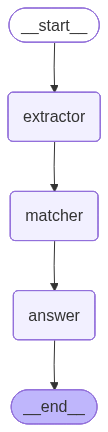

In [ ]:
from langchain_community.llms import Ollama  # Ollama LLM 사용
from langchain_core.prompts import PromptTemplate  # 프롬프트 템플릿
from langgraph.graph import StateGraph, END  # LangGraph 상태 머신
from typing import TypedDict  # 타입 정의용


# 1. 상태 정의 : 각 에이전트가 단계별로 내뱉는걸 담는 그릇 (Bowl)
class AgentState(TypedDict):  # 상태 타입 정의
    query: str  # 사용자 질의
    symptoms: str  # 추출된 증상
    exercise_candidates : str  # 운동 후보
    result: str  # 최종 응답


# 2. LLM 초기화
llm = Ollama(model="exaone3.5:2.4b")  # Ollama 모델 로딩


# 3. 에이전트 정의
# 사용자 질문에서 증상을 추출하려고 추출에이전트에 넣을 질의
extractor_prompt = PromptTemplate.from_template("""
                                                사용자의 질문에서 신체 상태나 증상에 해당하는 단어 또는 구를 추출하세요.  
                                                결과는 쉼표로 구분된 문자열로 출력하세요.  
                                                질문: {query}
                                                """)  # 증상 추출 프롬프트

# 에이전트 모듈함수 (인자에 반드시 Agent State 넣어야 함. (2 in 1 구조에서 예외가 있긴 함))
def extractor_agent(state: AgentState):  # 증상 추출 함수
    chain = extractor_prompt | llm  # 프롬프트 체인 (LCEL)
    symptoms = chain.invoke({"query": state["query"]})  # LLM 실행
    return {**state, "symptoms": symptoms.strip()}  # AgentState 클래스에 state 인스턴스에 symptoms 변수값을 수정하는 부분

# 추출에이전트에서 뽑은 symptoms를 가지고 질병 3개를 추론하는 의사 에이전트
matcher_prompt = PromptTemplate.from_template("""
                                                다음 증상(상태) 목록을 바탕으로 이를 개선하고 해결하는 데 가장 도움이 되는 운동 3가지를 쉼표로 구분하여 추천해주세요.
                                                증상: {symptoms}
                                                """)  # 운동 후보 추정 프롬프트

# 추출에이전트에서 얻은 증상을 가지고 운동 후보를 추론하는 파이프 함수
def matcher_agent(state: AgentState):  # 운동 후보 추정
    chain = matcher_prompt | llm # LCEL
    candidates = chain.invoke({"symptoms": state["symptoms"]}) # state['symptoms']: AgentState 클래스의 인스턴스(state)에서 symptoms 값을 가져와서 질의로 던짐
    return {**state, "exercise_candidates": candidates.strip()}

# 
answer_prompt = PromptTemplate.from_template("""
                                            사용자의 현재 증상(상태): {symptoms}
                                            
                                            추천 운동 후보: {exercise_candidates}
                                            
                                            위 내용을 바탕으로 사용자의 현재 증상과 그에 맞는 추천 운동 리스트를 한눈에 보기 쉬운 개조식(bullet points)으로 정리하여 답변을 생성해주세요.
                                            """)  # 최종 응답 생성 프롬프트

# 최종답변 함수
def answer_agent(state: AgentState):  # 응답 생성 에이전트
    chain = answer_prompt | llm  # 프롬프트와 LLM을 연결하여 실행 체인 구성
    answer = chain.invoke({
        "symptoms": state["symptoms"], # Agent State의 인스턴스인 state의 symptoms 값 가져옴
        "exercise_candidates": state["exercise_candidates"] # AgentState의 인스턴스인 state의 exercise_candidates 값 가져옴
    })
    return {**state, "result": answer.strip()}


# 4. LangGraph 정의
from langgraph.graph import StateGraph  # LangGraph 구성 요소

graph = StateGraph(AgentState)  # 그래프 정의
graph.add_node("extractor", extractor_agent)  # 노드 추가
graph.add_node("matcher", matcher_agent)
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")  # 시작 노드 설정
graph.add_edge("extractor", "matcher")  # 노드 간 연결 정의
graph.add_edge("matcher", "answer")
graph.add_edge("answer", END)  # 종료 노드 설정

app = graph.compile()  # 그래프 컴파일


# 5. 실행 테스트
if __name__ == "__main__":
    initial_state = {
        "query": "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?",
        "symptoms": "",
        "exercise_candidates": "",
        "result": ""
    }
    
    # LangGraph 실행
    final_state = app.invoke(initial_state)
    
    print("============================== 최종 답변:")
    print(final_state["result"])
from IPython.display import Image, display

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))